# MountainCar — analyze a training run

Auto-discovers the latest `runs/mountaincar/<timestamp>/` directory, plots training curves, renders a value heatmap + policy quiver over the (position, velocity) grid, and embeds `eval.mp4`.

To analyze a specific run instead (e.g. the lecturer's pre-shipped sample), edit the `RUN_DIR` cell below.

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Locate workshop-1/ regardless of whether the notebook was started from the
# repo root, the workshop-1/ dir, or the 2-mountaincar/ dir.
_HERE = Path.cwd()
WORKSHOP1 = next(
    (
        p for p in [
            _HERE,
            _HERE.parent,
            _HERE.parent.parent,
            _HERE / 'workshop-1',
        ]
        if (p / '1-ppo' / 'ppo' / '__init__.py').exists()
    ),
    None,
)
if WORKSHOP1 is None:
    raise RuntimeError(
        'Could not locate workshop-1/. Run this notebook from the repo root '
        'or its containing stage directory.'
    )
sys.path.insert(0, str(WORKSHOP1 / '1-ppo'))

import gymnasium as gym  # noqa: E402
from ppo import PPOAgent  # noqa: E402

REPO_ROOT = WORKSHOP1.parent
print(f'workshop-1/ resolved to: {WORKSHOP1}')

In [2]:
# Set RUN_DIR to a specific path to override auto-discovery. Example:
#   RUN_DIR = 'pretrained/sample-runs/mountaincar/sample'
RUN_DIR = None

In [3]:
def find_latest_run() -> Path:
    candidates = [p for p in (REPO_ROOT / 'runs' / 'mountaincar').glob('*') if p.is_dir()]
    if not candidates:
        raise RuntimeError(
            "no runs found under runs/mountaincar/. Train one first via "
            "'uv run python workshop-1/2-mountaincar/train.py', or set "
            "RUN_DIR = 'pretrained/sample-runs/mountaincar/sample'."
        )
    return max(candidates, key=lambda p: p.stat().st_mtime)

run_dir = Path(RUN_DIR) if RUN_DIR is not None else find_latest_run()
if not run_dir.is_absolute():
    run_dir = (REPO_ROOT / run_dir).resolve()
print(f'Loading run: {run_dir}')

meta = json.loads((run_dir / 'meta.json').read_text())
print(f"  status      = {meta['status']}")
print(f"  agent_class = {meta['agent_class']}")
print(f"  timesteps   = {meta['total_timesteps']:,}")
print(f"  seed        = {meta['seed']}")

metrics_path = run_dir / 'metrics.jsonl'
if metrics_path.exists() and metrics_path.stat().st_size > 0:
    metrics = pd.read_json(metrics_path, lines=True)
    print(f'  records     = {len(metrics)}')
else:
    metrics = pd.DataFrame()
    print('  records     = 0 (training did not produce records)')

Loading run: /Users/mortenblorstad/projects/phd/RL-workshop/runs/mountaincar/20260429-083818
  status      = ok
  agent_class = MountainCarPPOAgent
  timesteps   = 200,000
  seed        = 42
  records     = 97


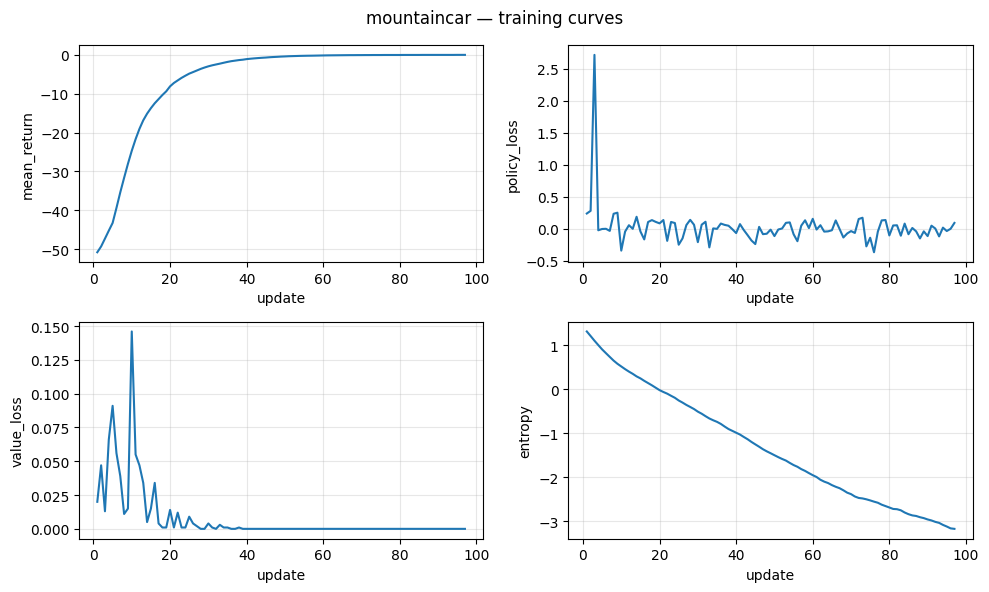

In [4]:
if not metrics.empty:
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    for ax, key in zip(axes.flat, ['mean_return', 'policy_loss', 'value_loss', 'entropy']):
        if key in metrics.columns:
            ax.plot(metrics['update'], metrics[key])
        ax.set_xlabel('update')
        ax.set_ylabel(key)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"{meta['stage']} — training curves")
    fig.tight_layout()
    plt.show()
else:
    print('No metrics records — skipping curves.')

In [ ]:
# Value heatmap over the 2-D (position, velocity) state space.
model_pt = run_dir / 'model.pt'
if model_pt.exists():
    env = gym.make(meta['env_id'])
    agent = PPOAgent.load(str(model_pt), env)
    pos = np.linspace(-1.2, 0.6, 50)
    vel = np.linspace(-0.07, 0.07, 50)
    P, V = np.meshgrid(pos, vel)
    grid = np.stack([P.ravel(), V.ravel()], axis=1).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(agent.device)
    with torch.no_grad():
        values = agent.critic(grid_t).cpu().numpy().reshape(P.shape)
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(
        values,
        extent=[pos[0], pos[-1], vel[0], vel[-1]],
        origin='lower', aspect='auto', cmap='viridis',
    )
    ax.set_xlabel('position')
    ax.set_ylabel('velocity')
    ax.set_title('Value function V(s)')
    fig.colorbar(im, ax=ax)
    plt.show()
    env.close()
else:
    print('No model.pt — skipping value heatmap.')

In [ ]:
# Policy mean action quiver. MountainCar action is 1-D continuous in [-1, 1];
# we draw horizontal arrows whose length encodes the action magnitude.
if model_pt.exists():
    env = gym.make(meta['env_id'])
    agent = PPOAgent.load(str(model_pt), env)
    pos_q = np.linspace(-1.2, 0.6, 20)
    vel_q = np.linspace(-0.07, 0.07, 20)
    Pq, Vq = np.meshgrid(pos_q, vel_q)
    grid_q = np.stack([Pq.ravel(), Vq.ravel()], axis=1).astype(np.float32)
    grid_t = torch.from_numpy(grid_q).to(agent.device)
    with torch.no_grad():
        actions = agent.actor(grid_t).cpu().numpy().reshape(*Pq.shape, -1)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.quiver(Pq, Vq, actions[..., 0], np.zeros_like(actions[..., 0]), scale=15)
    ax.set_xlabel('position')
    ax.set_ylabel('velocity')
    ax.set_title('Policy mean action (horizontal component)')
    plt.show()
    env.close()
else:
    print('No model.pt — skipping policy quiver.')

In [8]:
# Embed the greedy eval episode video (or surface a clear message if missing).
from IPython.display import Video, Markdown, display

eval_mp4 = run_dir / 'eval.mp4'
eval_skipped = run_dir / 'eval.mp4.skipped'
if eval_mp4.exists():
    display(Video(str(eval_mp4), embed=True, html_attributes='controls'))
elif eval_skipped.exists():
    display(Markdown(f"**No eval video for this run.** Reason:\n\n```\n{eval_skipped.read_text()}\n```"))
else:
    display(Markdown('*No eval video available for this run.*'))